# 14 · `tripcolor`

`Map.tripcolor` triangulates scattered/point data and renders **flat-shaded triangles** (cleopatra `MeshGlyph`). Any point set works; here the (coarse) DEM cell centres are triangulated.

**Setup** — inline plots and the path to the bundled Lisbon DEM.

In [1]:
%matplotlib inline
from pathlib import Path

# Locate the bundled Lisbon DEM from the repo root (works from docs/ or the repo root).
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
from pyramids.dataset import Dataset
from digitalearth.scene import Map
ds = Dataset.read_file(DEM)
coarse = ds.resample(ds.cell_size * 10)   # downsample for legible markers/cells

2026-05-28 20:30:25 | INFO | pyramids.base.config | Logging is configured.


Triangulate the coarse cell centres and render with `Map.tripcolor`.

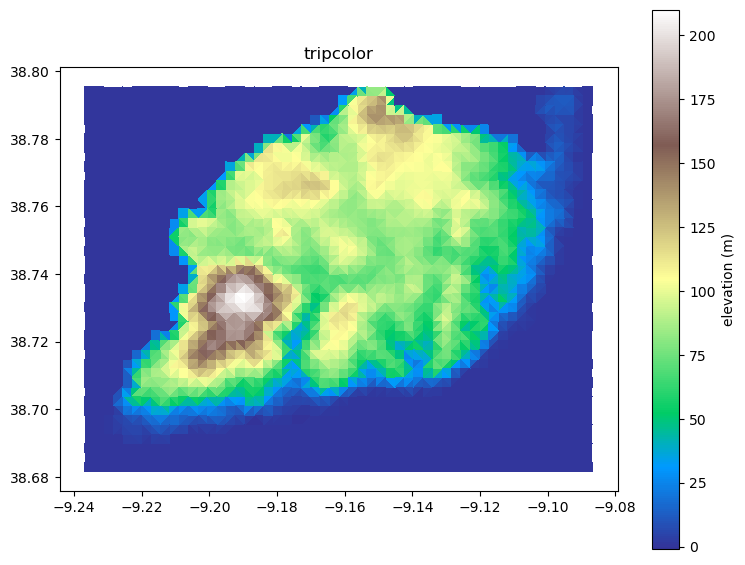

In [2]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.tripcolor(coarse, cmap='terrain')
m.colorbar(label='elevation (m)')
m.set_title('tripcolor')
m.fig;